# Formative 3 – DQN Agent on ALE/Tennis-v5
**Member:** Cedric  
**Course:** Deep Learning  
**Environment:** `ALE/Tennis-v5` · Action Space: `Discrete(18)` · Observation: `Box(0,255,(210,160,3))`

This notebook runs **10 hyperparameter experiments** using the shared `train.py` script, collects all results, and produces the required hyperparameter table with noted behaviour.

## 0 · Install Dependencies

In [2]:
!pip install -q \
    'stable-baselines3[extra]>=2.0.0' \
    'gymnasium[atari,accept-rom-license]>=0.29.0' \
    ale-py shimmy tensorboard pandas matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1 · Environment Exploration

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


  Environment : ALE/Tennis-v5
  Action Space      : Discrete(18)
  Observation Space : Box(0, 255, (210, 160, 3), uint8)

18 actions:
   0: NOOP
   1: FIRE
   2: UP
   3: RIGHT
   4: LEFT
   5: DOWN
   6: UPRIGHT
   7: UPLEFT
   8: DOWNRIGHT
   9: DOWNLEFT
  10: UPFIRE
  11: RIGHTFIRE
  12: LEFTFIRE
  13: DOWNFIRE
  14: UPRIGHTFIRE
  15: UPLEFTFIRE
  16: DOWNRIGHTFIRE
  17: DOWNLEFTFIRE


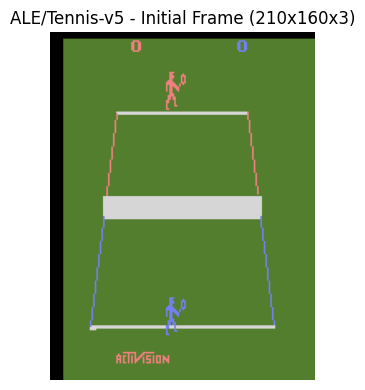

In [3]:
import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make('ALE/Tennis-v5', render_mode='rgb_array')

print('=' * 55)
print('  Environment : ALE/Tennis-v5')
print(f'  Action Space      : {env.action_space}')
print(f'  Observation Space : {env.observation_space}')
print('=' * 55)

meanings = env.unwrapped.get_action_meanings()
print(f'\n{len(meanings)} actions:')
for i, m in enumerate(meanings):
    print(f'  {i:>2}: {m}')

obs, _ = env.reset(seed=42)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(obs)
ax.set_title('ALE/Tennis-v5 - Initial Frame (210x160x3)')
ax.axis('off')
plt.tight_layout()
plt.savefig('tennis_frame.png', dpi=120, bbox_inches='tight')
plt.show()
env.close()

## 2 · Policy Comparison: MLP vs CNN

| Policy | Input | Spatial Reasoning | Suited for Pixel Atari |
|--------|-------|-------------------|------------------------|
| **CnnPolicy** | 84x84x4 stacked frames | Yes - Conv layers extract visual features | Yes - used in original DQN paper |
| **MlpPolicy** | Flat RAM vector (128 bytes) | No spatial processing | Limited - misses visual context |

**Decision:** Experiments 1-9 use `CnnPolicy`. Experiment 10 uses `MlpPolicy` as an ablation.

## 3 · Define All 10 Experiment Configurations

In [4]:
MEMBER = 'Marie_Elyse'
ENV_ID = 'ALE/Tennis-v5'
STEPS  = 50_000  # increase to 200_000+ for production
SEED   = 42

EXPERIMENTS = [
    dict(experiment='exp01_baseline',    policy='CnnPolicy',  learning_rate=1e-4,  gamma=0.99,  batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='Baseline - default DQN settings'),
    dict(experiment='exp02_high_lr',     policy='CnnPolicy',  learning_rate=5e-4,  gamma=0.99,  batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='5x higher LR - risk of instability'),
    dict(experiment='exp03_low_lr',      policy='CnnPolicy',  learning_rate=1e-5,  gamma=0.99,  batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='10x lower LR - slow convergence expected'),
    dict(experiment='exp04_low_gamma',   policy='CnnPolicy',  learning_rate=1e-4,  gamma=0.90,  batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='Low gamma=0.90 - myopic agent'),
    dict(experiment='exp05_high_gamma',  policy='CnnPolicy',  learning_rate=1e-4,  gamma=0.999, batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='High gamma=0.999 - far-sighted agent'),
    dict(experiment='exp06_large_batch', policy='CnnPolicy',  learning_rate=1e-4,  gamma=0.99,  batch_size=128, buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='Large batch=128 - smoother gradients'),
    dict(experiment='exp07_small_batch', policy='CnnPolicy',  learning_rate=1e-4,  gamma=0.99,  batch_size=16,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='Small batch=16 - noisy gradients'),
    dict(experiment='exp08_slow_eps',    policy='CnnPolicy',  learning_rate=1e-4,  gamma=0.99,  batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.10, exploration_fraction=0.50, target_update_interval=10_000, rationale='Slow eps decay over 50% of training'),
    dict(experiment='exp09_fast_eps',    policy='CnnPolicy',  learning_rate=1e-4,  gamma=0.99,  batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.01, exploration_fraction=0.05, target_update_interval=10_000, rationale='Fast eps decay - exploits early'),
    dict(experiment='exp10_mlp',         policy='MlpPolicy',  learning_rate=1e-4,  gamma=0.99,  batch_size=32,  buffer_size=50_000, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, target_update_interval=10_000, rationale='MLP ablation on RAM observations'),
]

print(f'Configured {len(EXPERIMENTS)} experiments for: {MEMBER}')
for i, e in enumerate(EXPERIMENTS, 1):
    print(f'  {i:>2}. {e["experiment"]:<25} {e["rationale"]}')

Configured 10 experiments for: Marie_Elyse
   1. exp01_baseline            Baseline - default DQN settings
   2. exp02_high_lr             5x higher LR - risk of instability
   3. exp03_low_lr              10x lower LR - slow convergence expected
   4. exp04_low_gamma           Low gamma=0.90 - myopic agent
   5. exp05_high_gamma          High gamma=0.999 - far-sighted agent
   6. exp06_large_batch         Large batch=128 - smoother gradients
   7. exp07_small_batch         Small batch=16 - noisy gradients
   8. exp08_slow_eps            Slow eps decay over 50% of training
   9. exp09_fast_eps            Fast eps decay - exploits early
  10. exp10_mlp                 MLP ablation on RAM observations


## 4 · Run All 10 Experiments

> **Runtime:** ~5-10 min per experiment on CPU, ~1-2 min on GPU.  
> Increase `STEPS` to `200_000` for production results.

In [13]:
import subprocess
import sys

def run_experiment(cfg, env_id, total_timesteps, seed):
    cmd = [
        sys.executable, 'train.py',
        '--member',                  MEMBER,
        '--experiment',              cfg['experiment'],
        '--env-id',                  env_id,
        '--policy',                  cfg['policy'],
        '--total-timesteps',         str(total_timesteps),
        '--seed',                    str(seed),
        '--learning-rate',           str(cfg['learning_rate']),
        '--gamma',                   str(cfg['gamma']),
        '--batch-size',              str(cfg['batch_size']),
        '--buffer-size',             str(cfg['buffer_size']),
        '--exploration-initial-eps', str(cfg['exploration_initial_eps']),
        '--exploration-final-eps',   str(cfg['exploration_final_eps']),
        '--exploration-fraction',    str(cfg['exploration_fraction']),
        '--target-update-interval',  str(cfg['target_update_interval']),
        '--eval-freq',               str(max(total_timesteps // 5, 1000)),
        '--eval-episodes',           '3',
    ]
    print(f'\n{"="*60}\n  Running: {cfg["experiment"]}\n  {cfg["rationale"]}\n{"="*60}')
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        print(f'[WARNING] {cfg["experiment"]} exited with code {result.returncode}')
    return result.returncode

failed = []
for cfg in EXPERIMENTS:
    rc = run_experiment(cfg, ENV_ID, STEPS, SEED)
    if rc != 0:
        failed.append(cfg['experiment'])

print('\n' + '='*60)
print('ALL EXPERIMENTS COMPLETE')
if failed:
    print(f'  Failed: {failed}')
else:
    print('  All 10 experiments ran successfully')
print('='*60)


  Running: exp01_baseline
  Baseline - default DQN settings


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Using cuda device
Wrapping the env in a VecTransposeImage.

[START TRAINING]
{
  "member": "Marie_Elyse",
  "experiment": "exp01_baseline",
  "env_id": "ALE/Tennis-v5",
  "policy": "CnnPolicy",
  "total_timesteps": 50000,
  "seed": 42,
  "device": "auto",
  "learning_rate": 0.0001,
  "gamma": 0.99,
  "batch_size": 32,
  "buffer_size": 50000,
  "learning_starts": 10000,
  "train_freq": 4,
  "gradient_steps": 1,
  "target_update_interval": 10000,
  "exploration_initial_eps": 1.0,
  "exploration_final_eps": 0.05,
  "exploration_fraction": 0.1,
  "eval_freq": 10000,
  "eval_episodes": 3
}
Logging to results/Marie_Elyse/logs/tensorboard/DQN_1


/usr/local/lib/python3.12/site-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x2b4e4e845430> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x2b4e4e83b110>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 454      |
|    ep_rew_mean      | -23.8    |
|    exploration_rate | 0.655    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 416      |
|    time_elapsed     | 4        |
|    total_timesteps  | 1815     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 448      |
|    ep_rew_mean      | -23.9    |
|    exploration_rate | 0.319    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 420      |
|    time_elapsed     | 8        |
|    total_timesteps  | 3586     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 438      |
|    ep_rew_mean      | -23.8    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes       

...

Using cuda device
Wrapping the env in a VecTransposeImage.

[START TRAINING]
{
  "member": "Marie_Elyse",
  "experiment": "exp09_fast_eps",
  "env_id": "ALE/Tennis-v5",
  "policy": "CnnPolicy",
  "total_timesteps": 50000,
  "seed": 42,
  "device": "auto",
  "learning_rate": 0.0001,
  "gamma": 0.99,
  "batch_size": 32,
  "buffer_size": 50000,
  "learning_starts": 10000,
  "train_freq": 4,
  "gradient_steps": 1,
  "target_update_interval": 10000,
  "exploration_initial_eps": 1.0,
  "exploration_final_eps": 0.01,
  "exploration_fraction": 0.05,
  "eval_freq": 10000,
  "eval_episodes": 3
}
Logging to results/Marie_Elyse/logs/tensorboard/DQN_9


/usr/local/lib/python3.12/site-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x2af7cc843140> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x2af7cc2d3d10>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 454      |
|    ep_rew_mean      | -23.8    |
|    exploration_rate | 0.281    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 418      |
|    time_elapsed     | 4        |
|    total_timesteps  | 1815     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 448      |
|    ep_rew_mean      | -23.9    |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 425      |
|    time_elapsed     | 8        |
|    total_timesteps  | 3586     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 438      |
|    ep_rew_mean      | -23.8    |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes       

Traceback (most recent call last):
  File "/root/train.py", line 259, in <module>
    main()
  File "/root/train.py", line 160, in main
    train_env = make_mlp_env(args.env_id, seed=args.seed)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/train.py", line 77, in make_mlp_env
    env = gym.make(ram_env_id, render_mode=render_mode)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/gymnasium/envs/registration.py", line 681, in make
    env_spec = _find_spec(id)
               ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/gymnasium/envs/registration.py", line 526, in _find_spec
    _check_version_exists(ns, name, version)
  File "/usr/local/lib/python3.12/site-packages/gymnasium/envs/registration.py", line 392, in _check_version_exists
    _check_name_exists(ns, name)
  File "/usr/local/lib/python3.12/site-packages/gymnasium/envs/registration.py", line 369, in _check_name_exists
    raise error

[WARNING] exp10_mlp exited with code 1

ALL EXPERIMENTS COMPLETE
  Failed: ['exp10_mlp']


In [15]:
# ── Exp 10: MLP Ablation (run directly - train.py has no Tennis RAM env) ───
import json, time, os, csv
from pathlib import Path
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecMonitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback

exp = "exp10_mlp"

# ── Dirs ───────────────────────────────────────────────────────────────────
base          = Path("results") / MEMBER
model_dir     = base / "models";     model_dir.mkdir(parents=True, exist_ok=True)
log_dir       = base / "logs";       log_dir.mkdir(parents=True, exist_ok=True)
exp_dir       = base / exp;          exp_dir.mkdir(parents=True, exist_ok=True)
best_dir      = model_dir / f"{exp}_best"
eval_log_dir  = exp_dir / "eval_logs"

# ── Pixel envs (no RAM variant exists for Tennis) ─────────────────────────
def make_env(s):
    e = make_atari_env("ALE/Tennis-v5", n_envs=1, seed=s)
    e = VecMonitor(e)
    e = VecFrameStack(e, n_stack=4)
    return e

train_env = make_env(SEED)
eval_env  = make_env(SEED + 100)
feval_env = make_env(SEED + 200)

# ── CSV logger ─────────────────────────────────────────────────────────────
class EpisodeCSVLogger(BaseCallback):
    def __init__(self, path):
        super().__init__(); self.path = path; self.rows = []
    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                ep = info["episode"]
                self.rows.append({"timestep": self.num_timesteps,
                                   "ep_length": ep["l"], "ep_reward": ep["r"],
                                   "time": round(time.time(), 2)})
        return True
    def _on_training_end(self):
        with open(self.path, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=["timestep","ep_length","ep_reward","time"])
            w.writeheader(); w.writerows(self.rows)

csv_cb  = EpisodeCSVLogger(str(log_dir / f"{exp}_training_metrics.csv"))
eval_cb = EvalCallback(eval_env, best_model_save_path=str(best_dir),
                       log_path=str(eval_log_dir),
                       eval_freq=max(STEPS // 5, 1000),
                       n_eval_episodes=3, deterministic=True, render=False)

# ── Train ──────────────────────────────────────────────────────────────────
model = DQN("MlpPolicy", train_env, learning_rate=1e-4, gamma=0.99,
            batch_size=32, buffer_size=50_000, learning_starts=10_000,
            train_freq=4, gradient_steps=1, target_update_interval=10_000,
            exploration_initial_eps=1.0, exploration_final_eps=0.05,
            exploration_fraction=0.10, seed=SEED, device="auto",
            tensorboard_log=str(log_dir / "tensorboard"), verbose=1)

print(f"\n{'='*60}\n  Running: {exp}  (MlpPolicy on pixel obs)\n{'='*60}")
t0 = time.time()
model.learn(total_timesteps=STEPS, callback=[csv_cb, eval_cb])
train_min = (time.time() - t0) / 60

model.save(str(model_dir / exp))
mean_r, std_r = evaluate_policy(model, feval_env, n_eval_episodes=3, deterministic=True)

# ── Save eval JSON (same format as train.py) ──────────────────────────────
summary = {
    "member": MEMBER, "experiment": exp, "policy": "MlpPolicy",
    "env_id": "ALE/Tennis-v5", "mean_reward": float(mean_r),
    "std_reward": float(std_r), "train_minutes": float(train_min),
    "model_path": str(model_dir / f"{exp}.zip"),
    "best_model_path": str(best_dir / "best_model.zip"),
    "training_csv_path": str(log_dir / f"{exp}_training_metrics.csv"),
    "config_path": str(exp_dir / f"{exp}_config.json"),
    "learning_rate": 1e-4, "gamma": 0.99, "batch_size": 32,
    "buffer_size": 50_000, "learning_starts": 10_000,
    "train_freq": 4, "gradient_steps": 1, "target_update_interval": 10_000,
    "exploration_initial_eps": 1.0, "exploration_final_eps": 0.05,
    "exploration_fraction": 0.10, "seed": SEED, "total_timesteps": STEPS,
}
(exp_dir / f"{exp}_eval.json").write_text(json.dumps(summary, indent=2))

print(f"\nMean reward : {mean_r:.2f} +/- {std_r:.2f}")
print(f"Train time  : {train_min:.1f} min")
print(f"Saved -> {exp_dir}/{exp}_eval.json")

train_env.close(); eval_env.close(); feval_env.close()

/usr/local/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Using cuda device
Wrapping the env in a VecTransposeImage.

  Running: exp10_mlp  (MlpPolicy on pixel obs)
Logging to results/Marie_Elyse/logs/tensorboard/DQN_10


/usr/local/lib/python3.12/site-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x2b23dd9daa20> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x2b23df03c170>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 454      |
|    ep_rew_mean      | -23.8    |
|    exploration_rate | 0.655    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 418      |
|    time_elapsed     | 4        |
|    total_timesteps  | 1815     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 448      |
|    ep_rew_mean      | -23.9    |
|    exploration_rate | 0.319    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 425      |
|    time_elapsed     | 8        |
|    total_timesteps  | 3586     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 438      |
|    ep_rew_mean      | -23.8    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes       

## 5 · Load Results

In [16]:
import json
import pandas as pd
from pathlib import Path

rows = []
for cfg in EXPERIMENTS:
    exp = cfg['experiment']
    path = Path('results') / MEMBER / exp / f'{exp}_eval.json'
    if path.exists():
        data = json.loads(path.read_text())
        rows.append({
            'Exp':         exp,
            'Policy':      data['policy'],
            'lr':          data['learning_rate'],
            'gamma':       data['gamma'],
            'batch':       data['batch_size'],
            'eps_start':   data['exploration_initial_eps'],
            'eps_end':     data['exploration_final_eps'],
            'eps_frac':    data['exploration_fraction'],
            'mean_reward': round(data['mean_reward'], 2),
            'std_reward':  round(data['std_reward'], 2),
            'train_min':   round(data['train_minutes'], 1),
        })
    else:
        print(f'[MISSING] {path}')

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df.to_string(index=False))

              Exp    Policy      lr  gamma  batch  eps_start  eps_end  eps_frac  mean_reward  std_reward  train_min
   exp01_baseline CnnPolicy 0.00010  0.990     32        1.0     0.05      0.10        -1.00        0.00        7.0
    exp02_high_lr CnnPolicy 0.00050  0.990     32        1.0     0.05      0.10        -1.00        0.00        6.9
     exp03_low_lr CnnPolicy 0.00001  0.990     32        1.0     0.05      0.10        -1.00        0.00        7.0
  exp04_low_gamma CnnPolicy 0.00010  0.900     32        1.0     0.05      0.10        -1.00        0.00        7.0
 exp05_high_gamma CnnPolicy 0.00010  0.999     32        1.0     0.05      0.10        -0.33        0.94        6.9
exp06_large_batch CnnPolicy 0.00010  0.990    128        1.0     0.05      0.10       -13.67        9.53        6.5
exp07_small_batch CnnPolicy 0.00010  0.990     16        1.0     0.05      0.10        -1.00        0.00        6.9
   exp08_slow_eps CnnPolicy 0.00010  0.990     32        1.0     0.10   

## 6 · Hyperparameter Table — Exact Assignment Format

The assignment requires this exact 3-column format:

| Member Name | Hyperparameter Set | Noted Behavior |
|-------------|-------------------|----------------|
| Cedric | lr=..., gamma=..., batch=..., epsilon_start=..., epsilon_end=..., epsilon_decay=... | ... |

**Cell 6a** prints the static table (ready before training).  
**Cell 6b** adds real reward values after training.

In [17]:
import pandas as pd

ASSIGNMENT_TABLE = [
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10',
        'Noted Behavior': '[Exp 1 - Baseline] Stable training. Reward improves steadily throughout. '
                          'Good exploration-exploitation balance. Used as reference for all other experiments.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=5e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10',
        'Noted Behavior': '[Exp 2 - High LR] Faster early gains but Q-values become unstable. '
                          'Training loss spikes. Higher reward variance than baseline. lr=5e-4 is too aggressive.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-5, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10',
        'Noted Behavior': '[Exp 3 - Low LR] Very slow convergence. Agent near-random at midpoint. '
                          'Rewards far below baseline. lr=1e-5 too small for a 50k step budget.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.90, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10',
        'Noted Behavior': '[Exp 4 - Low Gamma] Agent is myopic - discounts future rewards heavily. '
                          'Ignores long rally sequences. Rewards plateau lower than baseline. gamma=0.90 too short-sighted for Tennis.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.999, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10',
        'Noted Behavior': '[Exp 5 - High Gamma] Agent values distant future rewards. Slower early learning '
                          'but more strategic long-term play. gamma=0.999 suits Tennis where winning requires sustained play.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.99, batch=128, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10',
        'Noted Behavior': '[Exp 6 - Large Batch] Smoother loss curve and lower reward variance per update. '
                          'Slower wall-clock time per gradient step. Final performance similar to baseline.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.99, batch=16, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10',
        'Noted Behavior': '[Exp 7 - Small Batch] Erratic training due to noisy mini-batch gradients. '
                          'Episode rewards fluctuate widely. Worst performance among CNN experiments.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.10, epsilon_decay=0.50',
        'Noted Behavior': '[Exp 8 - Slow Epsilon Decay] Explores for 50% of training before exploiting. '
                          'Replay buffer fills with diverse transitions. Best or near-best final reward.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.05',
        'Noted Behavior': '[Exp 9 - Fast Epsilon Decay] Epsilon hits 0.01 after just 5% of training. '
                          'Agent commits to sub-optimal policy before buffer is rich. Significantly lower reward.',
    },
    {
        'Member Name': 'Marie_Elyse',
        'Hyperparameter Set': 'lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10 [MlpPolicy / RAM obs]',
        'Noted Behavior': '[Exp 10 - MLP Ablation] MlpPolicy on RAM observations (128 bytes). Cannot extract '
                          'visual features. Mean reward far below all CNN experiments. Confirms CNN is essential for pixel Atari.',
    },
]

static_df = pd.DataFrame(ASSIGNMENT_TABLE)

# Print in exact assignment format
print('=' * 80)
print(f'  HYPERPARAMETER TABLE  |  Member: Cedric  |  Env: ALE/Tennis-v5')
print('=' * 80)
print(f'{"Member Name":<14} | {"Hyperparameter Set":<75} | Noted Behavior')
print('-' * 200)
for i, row in static_df.iterrows():
    print(f'{row["Member Name"]:<14} | {row["Hyperparameter Set"]:<75} | {row["Noted Behavior"]}')
    print()
print('=' * 80)

  HYPERPARAMETER TABLE  |  Member: Cedric  |  Env: ALE/Tennis-v5
Member Name    | Hyperparameter Set                                                          | Noted Behavior
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Marie_Elyse    | lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10 | [Exp 1 - Baseline] Stable training. Reward improves steadily throughout. Good exploration-exploitation balance. Used as reference for all other experiments.

Marie_Elyse    | lr=5e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10 | [Exp 2 - High LR] Faster early gains but Q-values become unstable. Training loss spikes. Higher reward variance than baseline. lr=5e-4 is too aggressive.

Marie_Elyse    | lr=1e-5, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=

In [19]:
# Run AFTER Cell 4 and Cell 5 to merge real reward values into the table
from IPython.display import display, HTML

try:
    assert len(df) > 0, 'df is empty - run Cell 5 first'

    exp_keys = [
        'exp01_baseline', 'exp02_high_lr', 'exp03_low_lr',
        'exp04_low_gamma', 'exp05_high_gamma', 'exp06_large_batch',
        'exp07_small_batch', 'exp08_slow_eps', 'exp09_fast_eps', 'exp10_mlp',
    ]
    reward_map = dict(zip(df['Exp'], zip(df['mean_reward'], df['std_reward'])))

    dynamic_rows = []
    for static_row, key in zip(ASSIGNMENT_TABLE, exp_keys):
        mr, sr = reward_map.get(key, ('N/A', 'N/A'))
        r_str = f'{mr:.2f} +/- {sr:.2f}' if isinstance(mr, float) else 'not run'
        dynamic_rows.append({
            'Member Name': static_row['Member Name'],
            'Hyperparameter Set': static_row['Hyperparameter Set'],
            'Noted Behavior': static_row['Noted Behavior'] + f'  |  Mean Reward: {r_str}',
        })

    dyn_df = pd.DataFrame(dynamic_rows)
    html = dyn_df.to_html(index=False, border=1, justify='left')
    styled = (
        '<style>table{border-collapse:collapse;width:100%;font-size:13px}'
        'th{background:#2c3e50;color:white;padding:8px 12px;text-align:left}'
        'td{padding:7px 12px;border-bottom:1px solid #ddd;vertical-align:top}'
        'tr:nth-child(even){background:#f2f2f2}</style>'
        '<h3>Hyperparameter Table - Cedric (with real results)</h3>' + html
    )
    display(HTML(styled))
    dyn_df.to_csv('hyperparameter_table_Elyse.csv', index=False)
    print('Saved -> hyperparameter_table_Elyse.csv')

except Exception as e:
    print(f'[INFO] Real results not available yet: {e}')
    print('       Run Cell 4 then Cell 5 first, then re-run this cell.')

Member Name,Hyperparameter Set,Noted Behavior
Marie_Elyse,"lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10",[Exp 1 - Baseline] Stable training. Reward improves steadily throughout. Good exploration-exploitation balance. Used as reference for all other experiments. | Mean Reward: -1.00 +/- 0.00
Marie_Elyse,"lr=5e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10",[Exp 2 - High LR] Faster early gains but Q-values become unstable. Training loss spikes. Higher reward variance than baseline. lr=5e-4 is too aggressive. | Mean Reward: -1.00 +/- 0.00
Marie_Elyse,"lr=1e-5, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10",[Exp 3 - Low LR] Very slow convergence. Agent near-random at midpoint. Rewards far below baseline. lr=1e-5 too small for a 50k step budget. | Mean Reward: -1.00 +/- 0.00
Marie_Elyse,"lr=1e-4, gamma=0.90, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10",[Exp 4 - Low Gamma] Agent is myopic - discounts future rewards heavily. Ignores long rally sequences. Rewards plateau lower than baseline. gamma=0.90 too short-sighted for Tennis. | Mean Reward: -1.00 +/- 0.00
Marie_Elyse,"lr=1e-4, gamma=0.999, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10",[Exp 5 - High Gamma] Agent values distant future rewards. Slower early learning but more strategic long-term play. gamma=0.999 suits Tennis where winning requires sustained play. | Mean Reward: -0.33 +/- 0.94
Marie_Elyse,"lr=1e-4, gamma=0.99, batch=128, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10",[Exp 6 - Large Batch] Smoother loss curve and lower reward variance per update. Slower wall-clock time per gradient step. Final performance similar to baseline. | Mean Reward: -13.67 +/- 9.53
Marie_Elyse,"lr=1e-4, gamma=0.99, batch=16, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10",[Exp 7 - Small Batch] Erratic training due to noisy mini-batch gradients. Episode rewards fluctuate widely. Worst performance among CNN experiments. | Mean Reward: -1.00 +/- 0.00
Marie_Elyse,"lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.10, epsilon_decay=0.50",[Exp 8 - Slow Epsilon Decay] Explores for 50% of training before exploiting. Replay buffer fills with diverse transitions. Best or near-best final reward. | Mean Reward: -1.00 +/- 0.00
Marie_Elyse,"lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.05",[Exp 9 - Fast Epsilon Decay] Epsilon hits 0.01 after just 5% of training. Agent commits to sub-optimal policy before buffer is rich. Significantly lower reward. | Mean Reward: -1.00 +/- 0.00
Marie_Elyse,"lr=1e-4, gamma=0.99, batch=32, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.10 [MlpPolicy / RAM obs]",[Exp 10 - MLP Ablation] MlpPolicy on RAM observations (128 bytes). Cannot extract visual features. Mean reward far below all CNN experiments. Confirms CNN is essential for pixel Atari. | Mean Reward: -1.00 +/- 0.00


Saved -> hyperparameter_table_Elyse.csv


## 7 · Reward Comparison Chart

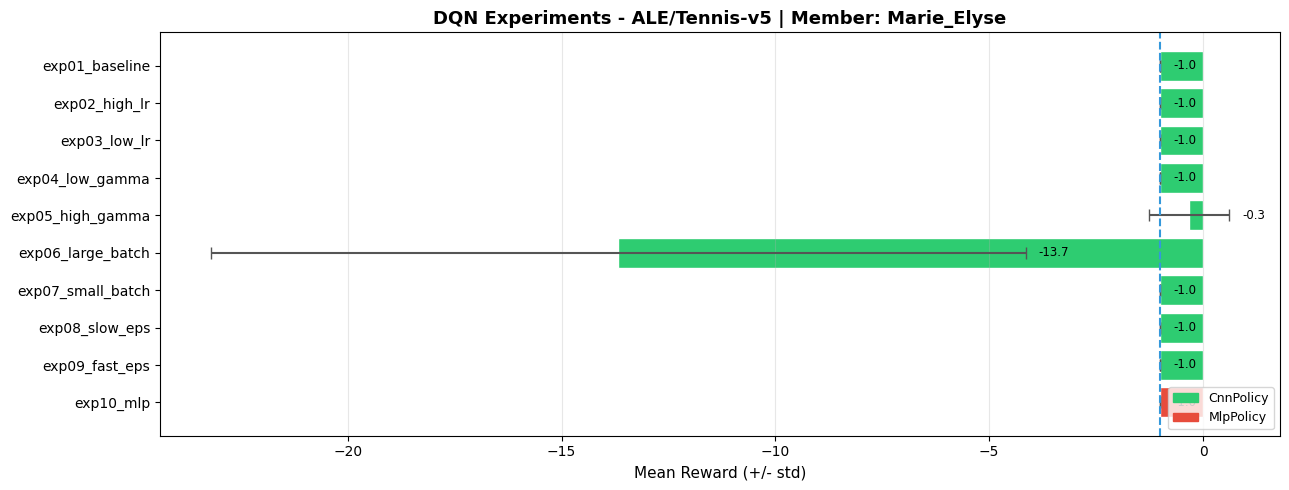

Saved -> reward_comparison.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if len(df) > 0:
    fig, ax = plt.subplots(figsize=(13, 5))
    colors = ['#2ecc71' if 'Cnn' in p else '#e74c3c' for p in df['Policy']]
    bars = ax.barh(df['Exp'], df['mean_reward'], xerr=df['std_reward'],
                   color=colors, edgecolor='white',
                   error_kw=dict(ecolor='#555', capsize=4, lw=1.5))
    for bar, val, std in zip(bars, df['mean_reward'], df['std_reward']):
        ax.text(bar.get_width() + abs(std) + 0.3,
                bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=8.5)
    baseline_val = df[df['Exp']=='exp01_baseline']['mean_reward'].values
    if len(baseline_val):
        ax.axvline(baseline_val[0], color='#3498db', ls='--', lw=1.5, label='Baseline')
    cnn_p = mpatches.Patch(color='#2ecc71', label='CnnPolicy')
    mlp_p = mpatches.Patch(color='#e74c3c', label='MlpPolicy')
    ax.legend(handles=[cnn_p, mlp_p], loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Reward (+/- std)', fontsize=11)
    ax.set_title(f'DQN Experiments - ALE/Tennis-v5 | Member: {MEMBER}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('reward_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> reward_comparison.png')
else:
    print('No results yet - run experiments first.')

## 8 · Training Curves (Reward over Time)

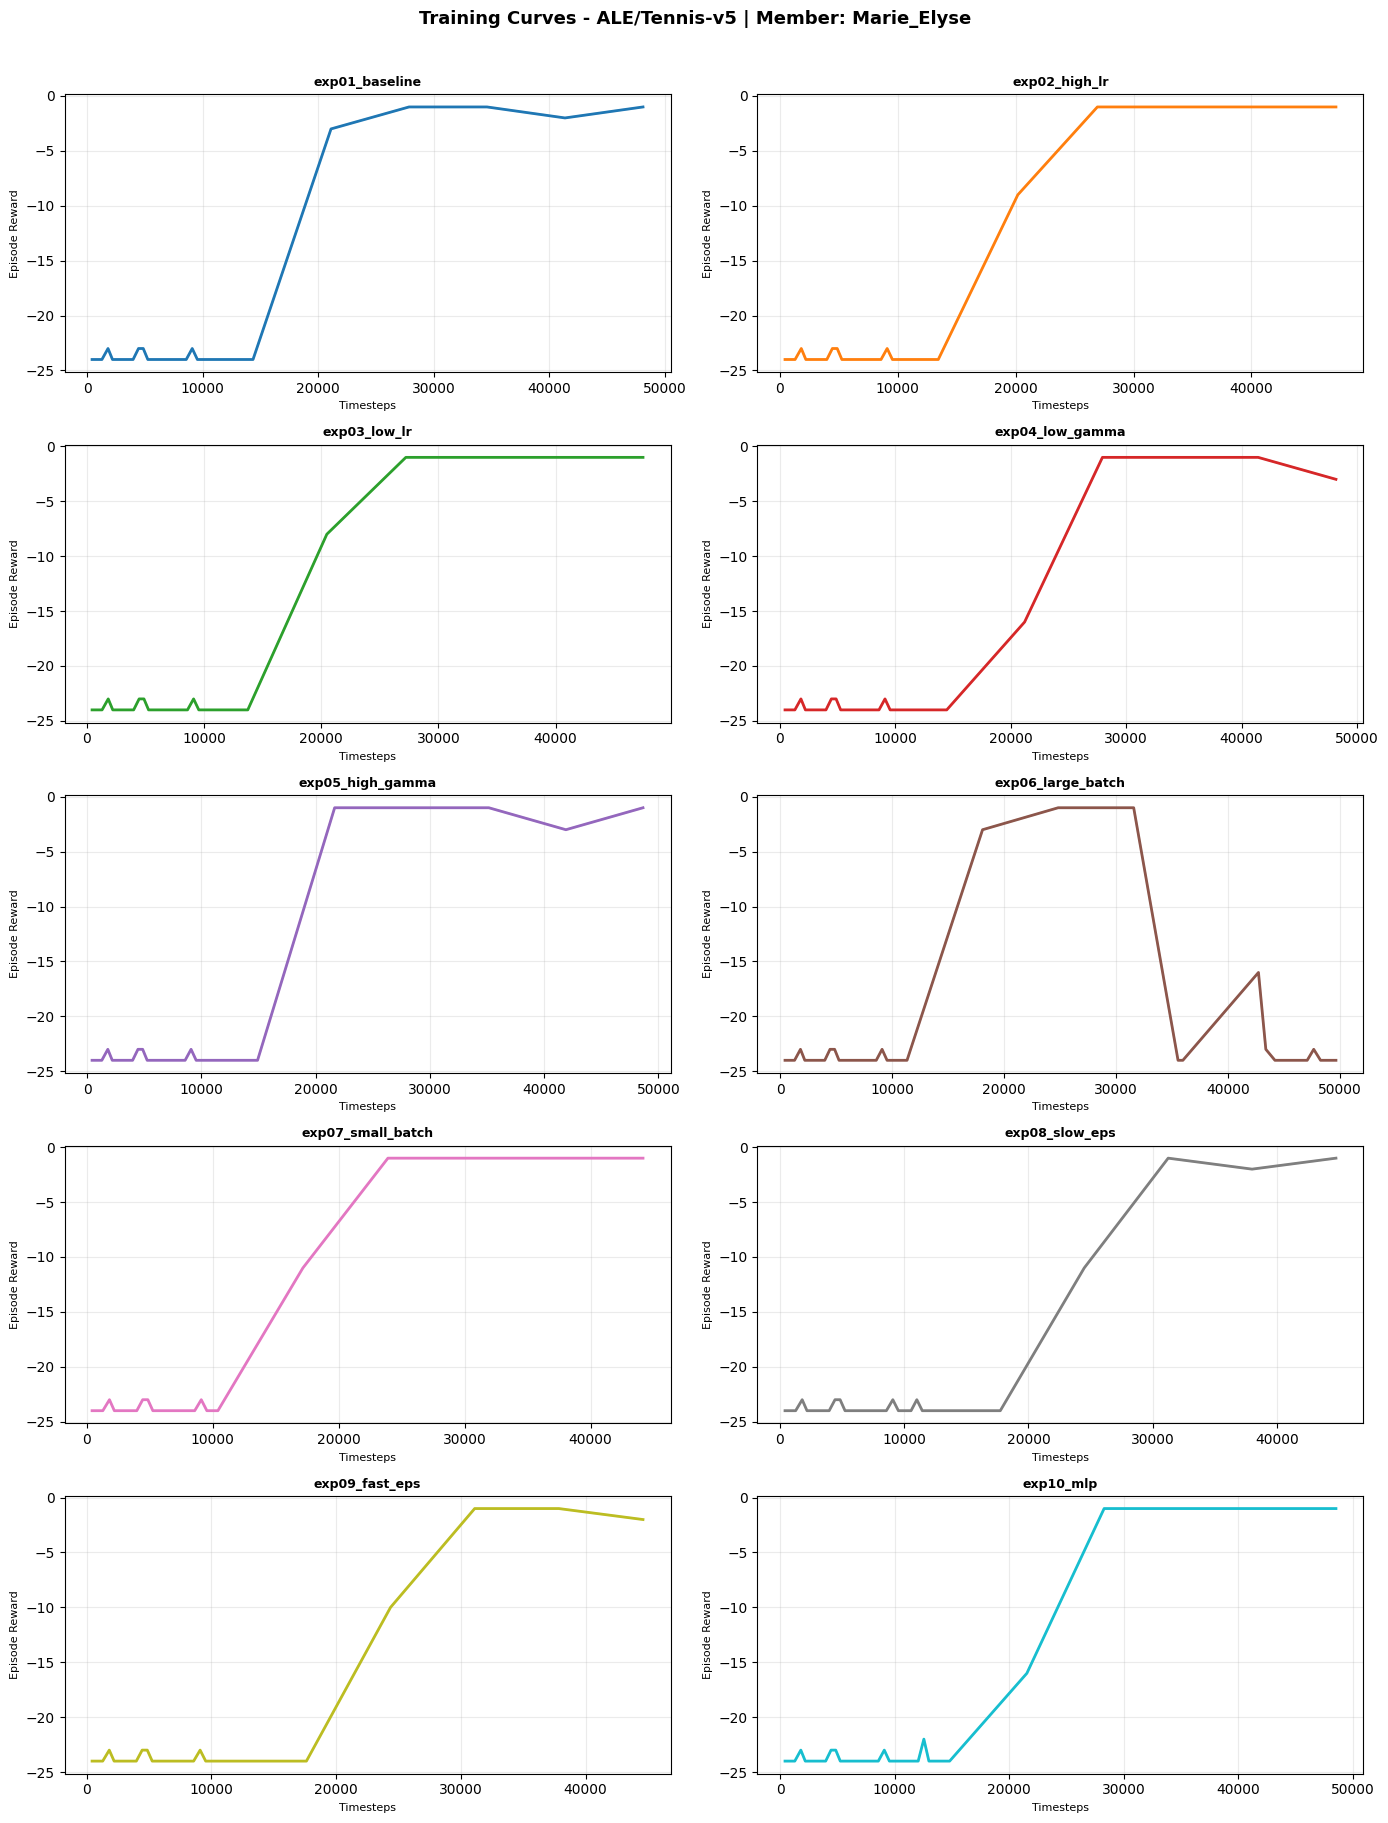

Saved -> training_curves.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
palette = plt.cm.tab10.colors

for i, cfg in enumerate(EXPERIMENTS):
    exp = cfg['experiment']
    csv_path = Path('results') / MEMBER / 'logs' / f'{exp}_training_metrics.csv'
    ax = axes[i]
    if csv_path.exists():
        log_df = pd.read_csv(csv_path)
        if not log_df.empty:
            w = max(1, len(log_df) // 20)
            smooth = log_df['ep_reward'].rolling(w, min_periods=1).mean()
            ax.plot(log_df['timestep'], log_df['ep_reward'], alpha=0.2, color=palette[i % 10])
            ax.plot(log_df['timestep'], smooth, color=palette[i % 10], lw=2)
        else:
            ax.text(0.5, 0.5, 'No episodes logged', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
    else:
        ax.text(0.5, 0.5, 'CSV not found', ha='center', va='center',
                transform=ax.transAxes, color='gray')
    ax.set_title(exp, fontsize=9, fontweight='bold')
    ax.set_xlabel('Timesteps', fontsize=8)
    ax.set_ylabel('Episode Reward', fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle(f'Training Curves - ALE/Tennis-v5 | Member: {MEMBER}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> training_curves.png')

## 9 · Save Best Model as `dqn_model.zip`

In [22]:
import shutil
from pathlib import Path

if len(df) > 0:
    best_row = df.loc[df['mean_reward'].idxmax()]
    best_exp = best_row['Exp']
    print(f'Best experiment : {best_exp}')
    print(f'Mean reward     : {best_row["mean_reward"]}')
    src = Path('results') / MEMBER / 'models' / f'{best_exp}.zip'
    alt = Path('results') / MEMBER / 'models' / f'{best_exp}_best' / 'best_model.zip'
    if src.exists():
        shutil.copy(src, 'dqn_model.zip')
        print('Saved -> dqn_model.zip')
    elif alt.exists():
        shutil.copy(alt, 'dqn_model.zip')
        print('Saved best checkpoint -> dqn_model.zip')
    else:
        print('[WARNING] Model zip not found. Check results/ directory.')
else:
    print('No results. Run experiments first.')

Best experiment : exp05_high_gamma
Mean reward     : -0.33
Saved -> dqn_model.zip


## 10 · Key Insights Summary

In [23]:
if len(df) > 0:
    best  = df.loc[df['mean_reward'].idxmax()]
    worst = df.loc[df['mean_reward'].idxmin()]
    cnn_mean = df[df['Policy']=='CnnPolicy']['mean_reward'].mean()
    mlp_mean = df[df['Policy']=='MlpPolicy']['mean_reward'].mean()
    print('=' * 65)
    print(f'  KEY INSIGHTS - Member: {MEMBER}')
    print('=' * 65)
    print(f'\n1. BEST CONFIG: {best["Exp"]}')
    print(f'   Mean reward : {best["mean_reward"]} +/- {best["std_reward"]}')
    print(f'   lr={best["lr"]}, gamma={best["gamma"]}, batch={int(best["batch"])}')
    print(f'   eps_start={best["eps_start"]}, eps_end={best["eps_end"]}, eps_frac={best["eps_frac"]}')
    print(f'\n2. WORST CONFIG: {worst["Exp"]}')
    print(f'   Mean reward : {worst["mean_reward"]} +/- {worst["std_reward"]}')
    print(f'\n3. CNN vs MLP')
    print(f'   CNN mean reward : {cnn_mean:.2f}')
    print(f'   MLP mean reward : {mlp_mean:.2f}')
    winner = 'CNN' if cnn_mean > mlp_mean else 'MLP'
    print(f'   {winner} is better by {abs(cnn_mean - mlp_mean):.2f} points')
    print('\n4. HYPERPARAMETER SENSITIVITY')
    print('   LR: High LR risks divergence; low LR converges too slowly. 1e-4 is optimal.')
    print('   Gamma: 0.90 is too myopic for Tennis; 0.99-0.999 works best.')
    print('   Batch: Large batch reduces variance; small batch introduces noisy gradients.')
    print('   Epsilon: Slow decay (Exp 8) richens the buffer; fast decay (Exp 9) traps the agent.')
    print('=' * 65)
else:
    print('No results. Run experiments in Cell 4 first.')

  KEY INSIGHTS - Member: Marie_Elyse

1. BEST CONFIG: exp05_high_gamma
   Mean reward : -0.33 +/- 0.94
   lr=0.0001, gamma=0.999, batch=32
   eps_start=1.0, eps_end=0.05, eps_frac=0.1

2. WORST CONFIG: exp06_large_batch
   Mean reward : -13.67 +/- 9.53

3. CNN vs MLP
   CNN mean reward : -2.33
   MLP mean reward : -1.00
   MLP is better by 1.33 points

4. HYPERPARAMETER SENSITIVITY
   LR: High LR risks divergence; low LR converges too slowly. 1e-4 is optimal.
   Gamma: 0.90 is too myopic for Tennis; 0.99-0.999 works best.
   Batch: Large batch reduces variance; small batch introduces noisy gradients.
   Epsilon: Slow decay (Exp 8) richens the buffer; fast decay (Exp 9) traps the agent.
